# 06 — Resposta direta e foco

Avaliação da objetividade das respostas e sua relação com o acerto.

In [1]:
# Configuração comum dos estudos integrados
from pathlib import Path
import re
import math
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option('display.max_columns', 80)
pd.set_option('display.max_colwidth', 120)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['savefig.bbox'] = 'tight'
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.22

ARTEFATOS = {
    'unificado': 'result_unificado_final.xlsx',
    'ferramenta': 'result_ferramenta_final.xlsx',
    'chats': 'result_chats_final.xlsx',
}

PASTAS_PROVAVEIS = [
    Path('../artefatos'),
    Path('../../artefatos'),
    Path('artefatos'),
    Path('../'),
    Path('.'),
    Path('/mnt/data'),
]

def encontra_arquivo(nome):
    for pasta in PASTAS_PROVAVEIS:
        caminho = pasta / nome
        if caminho.exists():
            return caminho.resolve()
    raise FileNotFoundError(
        f'Arquivo não encontrado: {nome}. Coloque os artefatos em ../artefatos/, artefatos/ ou na mesma pasta do notebook.'
    )

NOMES_MODELOS = {
    'claude-haiku-4-5': 'Claude Haiku',
    'claude-opus-4-7': 'Claude Opus',
    'claude-sonnet-4-6': 'Claude Sonnet',
    'deepseek-v4-flash': 'DeepSeek Flash',
    'deepseek-v4-pro': 'DeepSeek Pro',
    'gpt-4o-mini': 'GPT 4o mini',
    'gpt-5.4': 'GPT 5.4',
    'gpt-5.4-mini': 'GPT 5.4 mini',
    'gpt-5.5': 'GPT 5.5',
    'std_chatgpt': 'ChatGPT comercial',
    'std_claude': 'Claude comercial',
}

def provedor(modelo):
    m = str(modelo).lower()
    if 'claude' in m:
        return 'Anthropic'
    if 'gpt' in m or 'chatgpt' in m:
        return 'OpenAI'
    if 'deepseek' in m:
        return 'DeepSeek'
    return 'Outro'

def prepara(df, origem_padrao=None):
    """Cria campos de leitura do TCC em memória. Não salva nenhuma base intermediária."""
    df = df.copy()
    if 'origem_resultado' not in df.columns:
        df['origem_resultado'] = origem_padrao or 'nao_informada'
    for col in [
        'avaliacao_final', 'concisao_score', 'avaliacao_gpt', 'avaliacao_opus',
        'avaliacao_humana', 'resposta_tokens_tiktoken', 'input_tokens', 'output_tokens',
        'custo_estimado_usd', 'n_invocacoes', 'latencia_s'
    ]:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col].replace('nao pertinente', np.nan), errors='coerce')
    if 'convergencia' in df.columns:
        df['convergencia'] = df['convergencia'].astype(bool)
    else:
        df['convergencia'] = np.nan
    df['acerto'] = df['avaliacao_final']
    df['resposta_direta'] = df['concisao_score']
    df['discordancia_avaliadores'] = ~df['convergencia']
    df['origem_legivel'] = df['origem_resultado'].map({
        'ferramenta': 'Ferramenta',
        'chat_comercial': 'Chat comercial'
    }).fillna(df['origem_resultado'])
    df['modelo_legivel'] = df['modelo'].map(NOMES_MODELOS).fillna(df['modelo'])
    df['provedor'] = df['modelo'].map(provedor)
    df['status_acerto'] = pd.cut(
        df['acerto'], bins=[-0.01, 0.01, 0.99, 1.01],
        labels=['Incorreta', 'Parcial', 'Correta']
    )
    df['acerto_total'] = (df['acerto'] == 1).astype(int)
    df['erro_total'] = (df['acerto'] == 0).astype(int)
    df['parcial'] = (df['acerto'] == 0.5).astype(int)
    df['nao_totalmente_correta'] = (df['acerto'] < 1).astype(int)
    return df

def ler_artefatos():
    caminhos = {k: encontra_arquivo(v) for k, v in ARTEFATOS.items()}
    df_unificado = prepara(pd.read_excel(caminhos['unificado']))
    df_ferramenta = prepara(pd.read_excel(caminhos['ferramenta']), 'ferramenta')
    df_chats = prepara(pd.read_excel(caminhos['chats']), 'chat_comercial')
    return caminhos, df_unificado, df_ferramenta, df_chats

caminhos, df, df_ferramenta, df_chats = ler_artefatos()
print('Artefatos lidos:')
for nome, caminho in caminhos.items():
    print(f'- {nome}: {caminho}')
print(f'Base unificada: {df.shape[0]} linhas x {df.shape[1]} colunas')

# Ordem padrão dos modelos: maior acerto médio primeiro.
ORDEM_MODELOS = (
    df.groupby('modelo_legivel')['acerto']
      .mean()
      .sort_values(ascending=False)
      .index
      .tolist()
)

def pct(x):
    if pd.isna(x):
        return ''
    return f'{100*x:.1f}%'

def dinheiro(x):
    if pd.isna(x):
        return ''
    return f'US$ {x:.5f}'

def resumo_metricas(data, grupo):
    g = data.groupby(grupo, observed=True)
    out = g.agg(
        n=('acerto', 'size'),
        acerto_medio=('acerto', 'mean'),
        taxa_correta=('acerto_total', 'mean'),
        taxa_parcial=('parcial', 'mean'),
        taxa_incorreta=('erro_total', 'mean'),
        resposta_direta=('resposta_direta', 'mean'),
        discordancia=('discordancia_avaliadores', 'mean'),
        tokens_resposta=('resposta_tokens_tiktoken', 'mean'),
    ).reset_index()
    return out

def ordena_por_modelo(series_or_df, col=None):
    if isinstance(series_or_df, pd.Series):
        return series_or_df.reindex([m for m in ORDEM_MODELOS if m in series_or_df.index])
    return series_or_df.set_index(col).reindex([m for m in ORDEM_MODELOS if m in series_or_df[col].values]).reset_index()

def barh_series(s, titulo, xlabel='', percentual=False, figsize=(8, 5), limite=None):
    s = s.dropna().copy()
    if limite is not None:
        s = s.sort_values(ascending=False).head(limite)
    else:
        s = s.sort_values(ascending=True)
    vals = s * 100 if percentual else s
    fig, ax = plt.subplots(figsize=figsize)
    ax.barh(vals.index.astype(str), vals.values)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel('')
    ax.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()

def bar_series(s, titulo, xlabel='', ylabel='', percentual=False, figsize=(8, 4), rot=0):
    s = s.dropna().copy()
    vals = s * 100 if percentual else s
    fig, ax = plt.subplots(figsize=figsize)
    ax.bar(vals.index.astype(str), vals.values)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=rot)
    ax.grid(axis='x', visible=False)
    plt.tight_layout()
    plt.show()

def stacked_percent(data, index_col, column_col, titulo, ordem_colunas=None, figsize=(9, 6)):
    tab = pd.crosstab(data[index_col], data[column_col], normalize='index')
    if ordem_colunas:
        tab = tab.reindex(columns=[c for c in ordem_colunas if c in tab.columns])
    tab = tab.loc[tab.sum(axis=1).sort_values().index]
    ax = (tab * 100).plot(kind='barh', stacked=True, figsize=figsize)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel('% das respostas')
    ax.set_ylabel('')
    ax.legend(title='', bbox_to_anchor=(1.02, 1), loc='upper left')
    ax.grid(axis='y', visible=False)
    plt.tight_layout()
    plt.show()
    return tab

def heatmap_tabela(pivot, titulo, formato='.1f', percentual=True, figsize=(9, 5)):
    dados = pivot.copy()
    valores = dados.values * 100 if percentual else dados.values
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(valores, aspect='auto')
    ax.set_title(titulo, loc='left')
    ax.set_xticks(np.arange(dados.shape[1]))
    ax.set_xticklabels(dados.columns.astype(str), rotation=35, ha='right')
    ax.set_yticks(np.arange(dados.shape[0]))
    ax.set_yticklabels(dados.index.astype(str))
    # Só anota quando a matriz é pequena o suficiente para não virar poluição visual.
    if dados.shape[0] * dados.shape[1] <= 80:
        for i in range(dados.shape[0]):
            for j in range(dados.shape[1]):
                val = valores[i, j]
                if not np.isnan(val):
                    texto = f'{val:{formato}}' + ('%' if percentual else '')
                    ax.text(j, i, texto, ha='center', va='center', fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02)
    plt.tight_layout()
    plt.show()

def boxplot_por_grupo(data, valor, grupo, titulo, ylabel='', figsize=(9, 5), ordem=None):
    base = data[[valor, grupo]].dropna()
    if ordem is None:
        ordem = base.groupby(grupo)[valor].median().sort_values().index.tolist()
    grupos = [base.loc[base[grupo] == g, valor].values for g in ordem if g in base[grupo].unique()]
    labels = [g for g in ordem if g in base[grupo].unique()]
    fig, ax = plt.subplots(figsize=figsize)
    ax.boxplot(grupos, labels=labels, vert=False, showfliers=False)
    ax.set_title(titulo, loc='left')
    ax.set_xlabel(ylabel or valor)
    ax.set_ylabel('')
    plt.tight_layout()
    plt.show()

def tabela_formatada(data, percent_cols=None, money_cols=None, round_cols=None, n=20):
    out = data.copy().head(n)
    percent_cols = percent_cols or []
    money_cols = money_cols or []
    round_cols = round_cols or []
    for c in percent_cols:
        if c in out.columns:
            out[c] = out[c].map(pct)
    for c in money_cols:
        if c in out.columns:
            out[c] = out[c].map(dinheiro)
    for c in round_cols:
        if c in out.columns:
            out[c] = out[c].round(3)
    display(out)

def texto_curto(s, n=180):
    if pd.isna(s):
        return ''
    s = re.sub(r'\s+', ' ', str(s)).strip()
    return s if len(s) <= n else s[:n-1] + '…'

Artefatos lidos:
- unificado: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_unificado_final.xlsx
- ferramenta: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_ferramenta_final.xlsx
- chats: /home/julio/Documentos/tcc_GENAI/v8/edital-assistant/eval/artefatos/result_chats_final.xlsx
Base unificada: 1650 linhas x 34 colunas


## Pergunta do estudo
Os modelos respondem de forma direta e focada ou adicionam informação desnecessária?

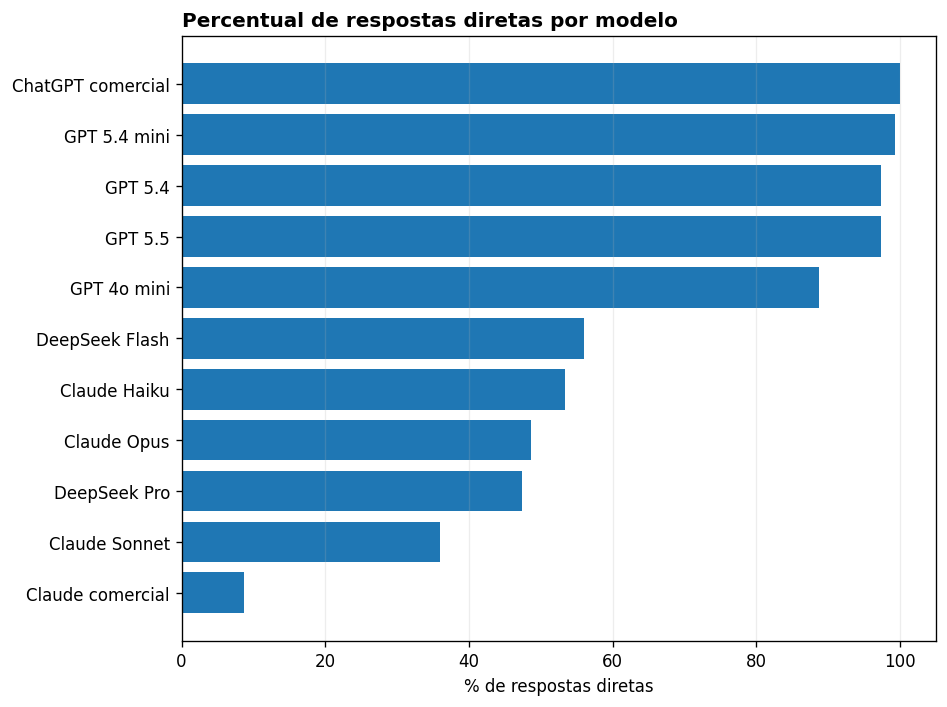

,modelo_legivel,n,acerto_medio,taxa_correta,taxa_parcial,taxa_incorreta,resposta_direta,discordancia,tokens_resposta
0,ChatGPT comercial,150,87.7%,81.3%,0.126667,6.0%,100.0%,7.3%,61.100
9,GPT 5.4 mini,150,90.7%,84.0%,0.133333,2.7%,99.3%,10.7%,100.133
8,GPT 5.4,150,96.3%,94.0%,0.046667,1.3%,97.3%,1.3%,107.413
10,GPT 5.5,150,99.7%,99.3%,0.006667,0.0%,97.3%,3.3%,117.207
7,GPT 4o mini,150,91.0%,84.7%,0.126667,2.7%,88.7%,10.0%,140.720
5,DeepSeek Flash,150,97.0%,94.0%,0.060000,0.0%,56.0%,5.3%,264.573
1,Claude Haiku,150,93.7%,88.0%,0.113333,0.7%,53.3%,11.3%,231.860
2,Claude Opus,150,97.7%,95.3%,0.046667,0.0%,48.7%,5.3%,271.707
6,DeepSeek Pro,150,96.3%,92.7%,0.073333,0.0%,47.3%,8.7%,296.453
3,Claude Sonnet,150,97.3%,94.7%,0.053333,0.0%,36.0%,5.3%,321.400


In [2]:
direta_modelo = df.groupby('modelo_legivel')['resposta_direta'].mean().reindex(ORDEM_MODELOS).sort_values()
barh_series(direta_modelo, 'Percentual de respostas diretas por modelo', '% de respostas diretas', percentual=True, figsize=(8, 6))
tabela = resumo_metricas(df, 'modelo_legivel').sort_values('resposta_direta', ascending=False)
tabela_formatada(tabela, percent_cols=['acerto_medio','resposta_direta','taxa_correta','taxa_incorreta','discordancia'], round_cols=['tokens_resposta'], n=20)

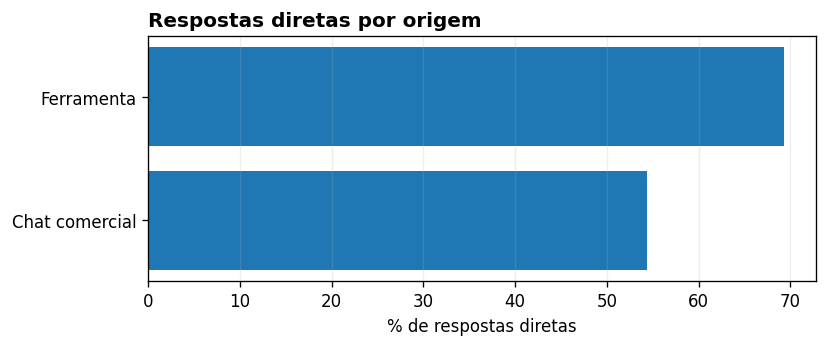

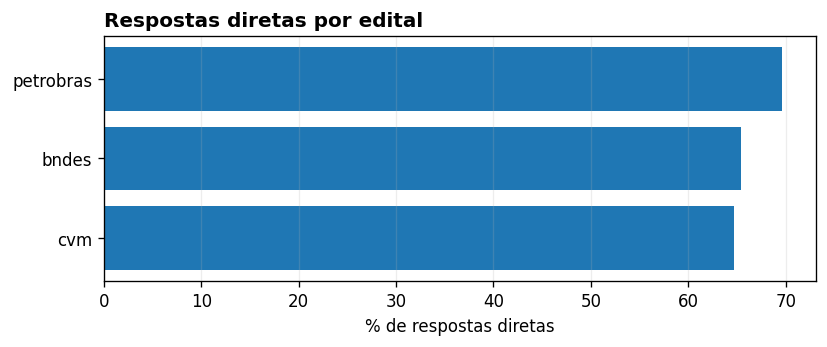

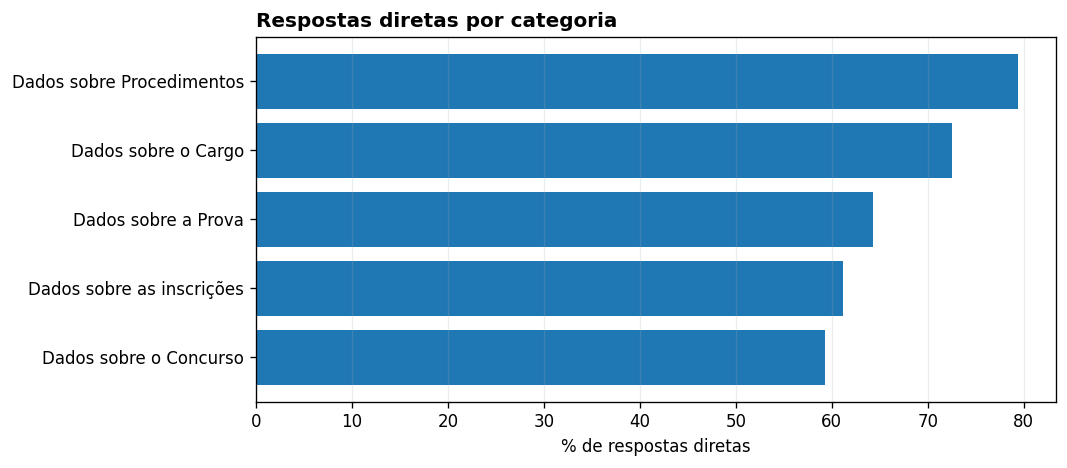

In [3]:
barh_series(df.groupby('origem_legivel')['resposta_direta'].mean().sort_values(), 'Respostas diretas por origem', '% de respostas diretas', percentual=True, figsize=(7, 3))
barh_series(df.groupby('edital')['resposta_direta'].mean().sort_values(), 'Respostas diretas por edital', '% de respostas diretas', percentual=True, figsize=(7, 3))
barh_series(df.groupby('categoria')['resposta_direta'].mean().sort_values(), 'Respostas diretas por categoria', '% de respostas diretas', percentual=True, figsize=(9, 4))

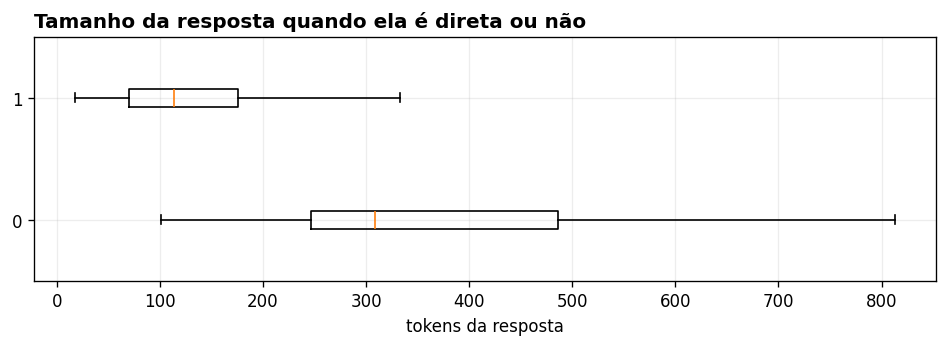

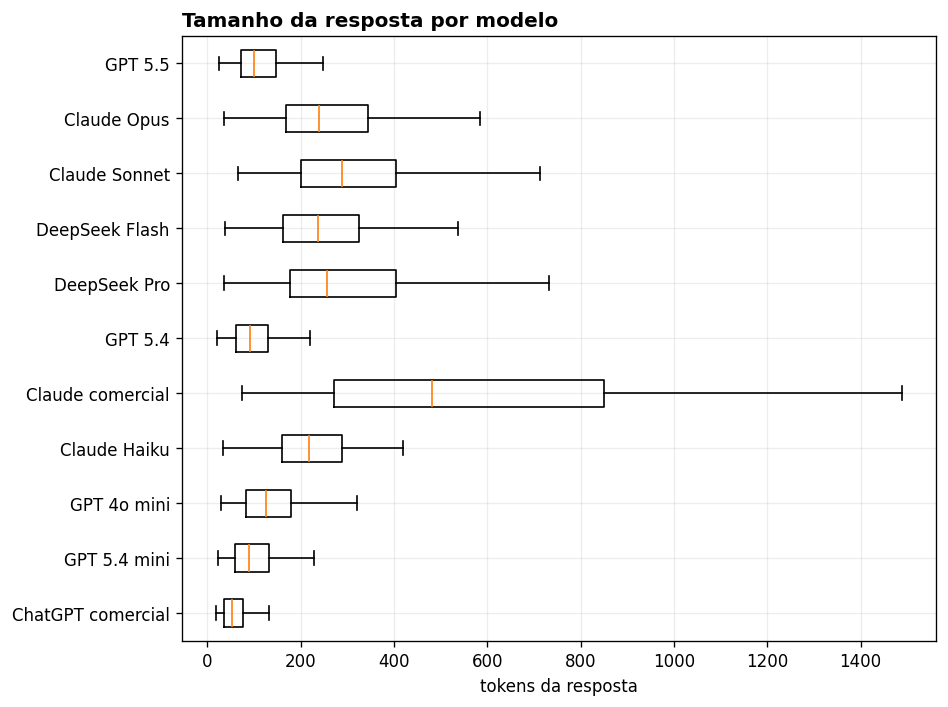

In [4]:
boxplot_por_grupo(df, 'resposta_tokens_tiktoken', 'resposta_direta', 'Tamanho da resposta quando ela é direta ou não', 'tokens da resposta', figsize=(8, 3), ordem=[0,1])
boxplot_por_grupo(df, 'resposta_tokens_tiktoken', 'modelo_legivel', 'Tamanho da resposta por modelo', 'tokens da resposta', figsize=(8, 6), ordem=ORDEM_MODELOS[::-1])

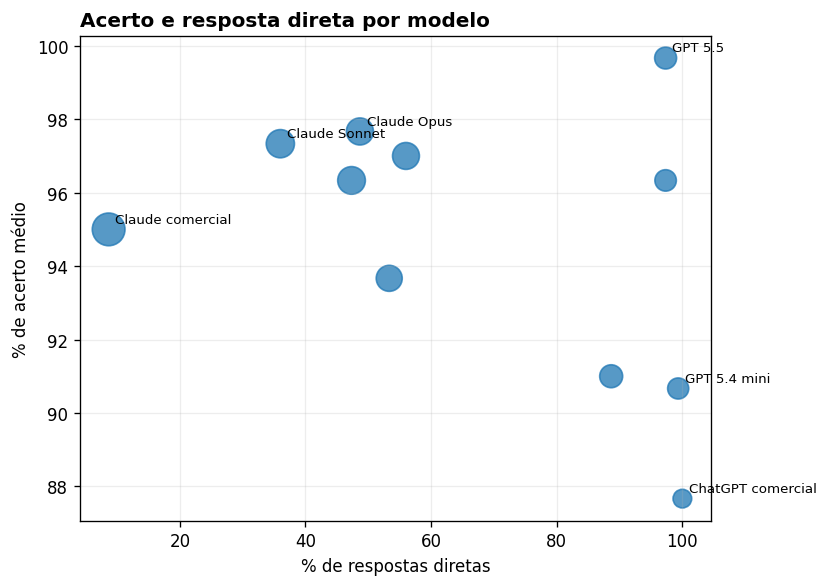

,modelo_legivel,acerto,direta,tokens,n
0,GPT 5.5,0.996667,0.973333,117.206667,150
1,Claude Opus,0.976667,0.486667,271.706667,150
2,Claude Sonnet,0.973333,0.360000,321.400000,150
3,DeepSeek Flash,0.970000,0.560000,264.573333,150
4,GPT 5.4,0.963333,0.973333,107.413333,150
5,DeepSeek Pro,0.963333,0.473333,296.453333,150
6,Claude comercial,0.950000,0.086667,581.413333,150
7,Claude Haiku,0.936667,0.533333,231.860000,150
8,GPT 4o mini,0.910000,0.886667,140.720000,150
9,GPT 5.4 mini,0.906667,0.993333,100.133333,150


In [5]:
# Relação entre acerto e resposta direta por modelo.
m = df.groupby('modelo_legivel').agg(acerto=('acerto','mean'), direta=('resposta_direta','mean'), tokens=('resposta_tokens_tiktoken','mean'), n=('acerto','size')).reindex(ORDEM_MODELOS)
fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(m['direta']*100, m['acerto']*100, s=np.sqrt(m['tokens'])*16, alpha=0.75)
ax.set_title('Acerto e resposta direta por modelo', loc='left')
ax.set_xlabel('% de respostas diretas')
ax.set_ylabel('% de acerto médio')
# Anota só os extremos para evitar sobreposição.
extremos = pd.concat([m.nlargest(2, 'acerto'), m.nlargest(2, 'direta'), m.nsmallest(2, 'direta')]).drop_duplicates()
for nome, row in extremos.iterrows():
    ax.annotate(nome, (row['direta']*100, row['acerto']*100), xytext=(4, 4), textcoords='offset points', fontsize=8)
plt.tight_layout()
plt.show()
display(m.sort_values(['acerto','direta'], ascending=False).reset_index())

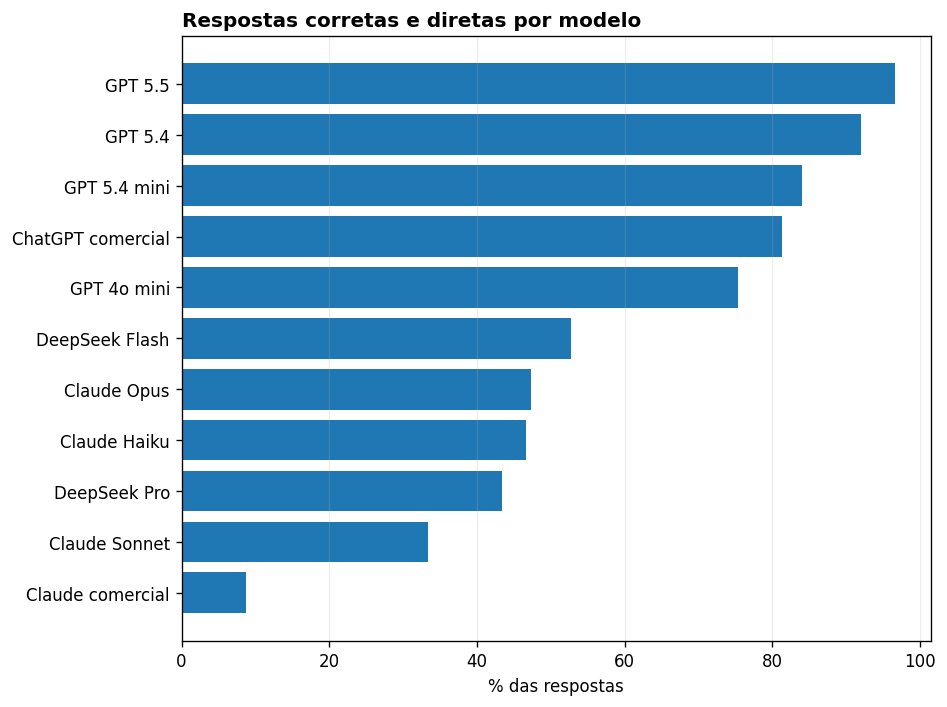

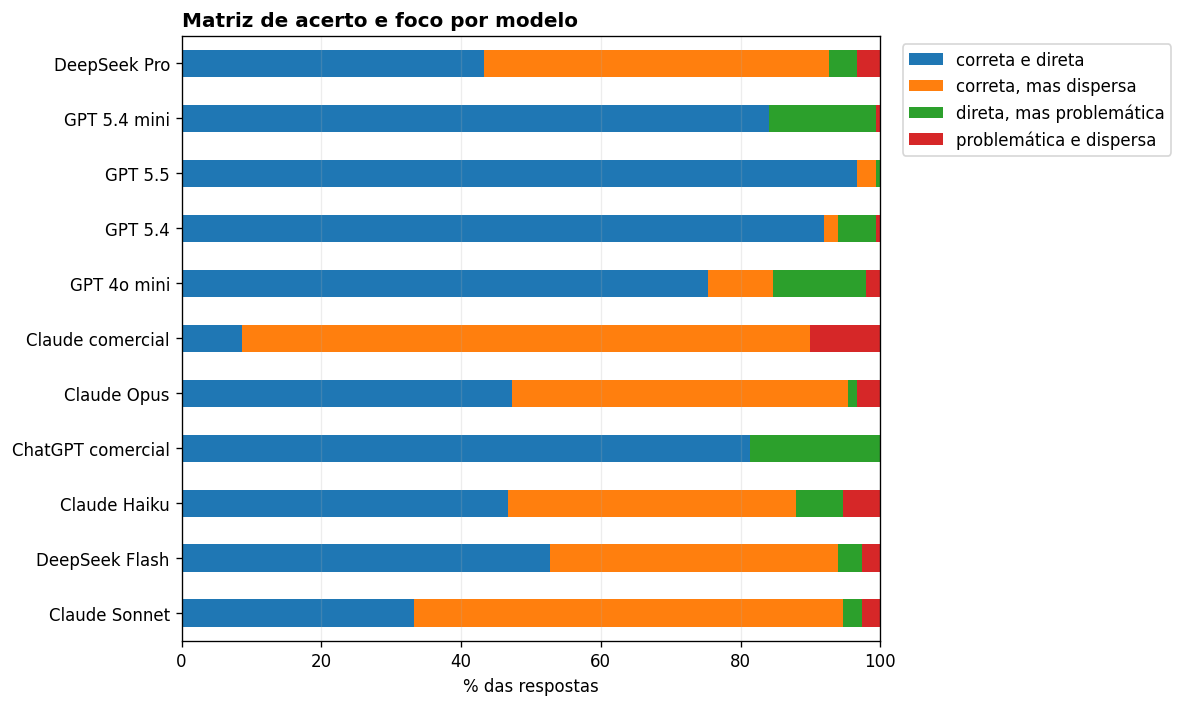

quadrante_acerto_foco,correta e direta,"correta, mas dispersa","direta, mas problemática",problemática e dispersa
modelo_legivel,,,,
Claude Sonnet,0.333333,0.613333,0.026667,0.026667
DeepSeek Flash,0.526667,0.413333,0.033333,0.026667
Claude Haiku,0.466667,0.413333,0.066667,0.053333
ChatGPT comercial,0.813333,0.000000,0.186667,0.000000
Claude Opus,0.473333,0.480000,0.013333,0.033333
Claude comercial,0.086667,0.813333,0.000000,0.100000
GPT 4o mini,0.753333,0.093333,0.133333,0.020000
GPT 5.4,0.920000,0.020000,0.053333,0.006667
GPT 5.5,0.966667,0.026667,0.006667,0.000000


In [6]:
df['quadrante_acerto_foco'] = np.select(
    [(df['acerto'] == 1) & (df['resposta_direta'] == 1),
     (df['acerto'] == 1) & (df['resposta_direta'] == 0),
     (df['acerto'] < 1) & (df['resposta_direta'] == 1),
     (df['acerto'] < 1) & (df['resposta_direta'] == 0)],
    ['correta e direta', 'correta, mas dispersa', 'direta, mas problemática', 'problemática e dispersa'],
    default='indefinido'
)
q = pd.crosstab(df['modelo_legivel'], df['quadrante_acerto_foco'], normalize='index')
# Foco nos dois quadrantes mais úteis para discussão.
barh_series(q.get('correta e direta', pd.Series(dtype=float)).sort_values(), 'Respostas corretas e diretas por modelo', '% das respostas', percentual=True, figsize=(8, 6))
stacked_percent(df, 'modelo_legivel', 'quadrante_acerto_foco', 'Matriz de acerto e foco por modelo', ordem_colunas=['correta e direta','correta, mas dispersa','direta, mas problemática','problemática e dispersa'], figsize=(10, 6))

In [7]:
exemplos = df[(df['acerto'] == 1) & (df['resposta_direta'] == 0)].copy()
exemplos['pergunta_curta'] = exemplos['pergunta'].map(lambda x: texto_curto(x, 140))
exemplos['justificativa_curta'] = exemplos['justificativa_concisao'].map(lambda x: texto_curto(x, 220))
display(Markdown('### Exemplos de respostas corretas, mas pouco diretas'))
display(exemplos[['origem_legivel','edital','modelo_legivel','categoria','resposta_tokens_tiktoken','pergunta_curta','justificativa_curta']].head(20))

### Exemplos de respostas corretas, mas pouco diretas

,origem_legivel,edital,modelo_legivel,categoria,resposta_tokens_tiktoken,pergunta_curta,justificativa_curta
1,Ferramenta,bndes,Claude Haiku,Dados sobre as inscrições,203,Qual o valor da taxa de inscrição do concurso BNDES?,"despejou pagamento, devolução e isenção sem pedir"
2,Ferramenta,bndes,Claude Haiku,Dados sobre as inscrições,113,Em qual site o candidato deve fazer a inscrição do concurso BNDES?,"despejou período, escolha de cargo e taxa sem pedir"
4,Ferramenta,bndes,Claude Haiku,Dados sobre as inscrições,346,Qual é o prazo-limite de pagamento da inscrição do concurso BNDES?,"despejou formas de pagamento, vedações e status sem pedir"
5,Ferramenta,bndes,Claude Haiku,Dados sobre as inscrições,344,Quem pode pedir isenção da taxa de inscrição do concurso BNDES?,"despejou procedimento, período e punição sem pedir"
6,Ferramenta,bndes,Claude Haiku,Dados sobre as inscrições,192,Qual é o período para solicitar isenção da taxa de inscrição do concurso BNDES?,despejou quem podia pedir e cronograma sem pedir
7,Ferramenta,bndes,Claude Haiku,Dados sobre as inscrições,232,A inscrição do concurso BNDES é feita somente pela internet?,"despejou procedimentos, taxa e pagamento sem pedir"
11,Ferramenta,bndes,Claude Haiku,Dados sobre o Concurso,286,Quantas fases ou etapas tem o concurso BNDES?,detalhou questões e critérios demais para perguntar quantidade
13,Ferramenta,bndes,Claude Haiku,Dados sobre o Concurso,302,Em quais cidades ou locais as provas do concurso BNDES serão realizadas?,"incluiu contato, alteração e instruções demais sem pedir"
14,Ferramenta,bndes,Claude Haiku,Dados sobre o Concurso,260,Qual horário de referência deve ser considerado pelo candidato no concurso BNDES?,listou vários exemplos e prazos além do horário pedido
15,Ferramenta,bndes,Claude Haiku,Dados sobre o Concurso,212,Onde o candidato encontra o cronograma oficial do concurso BNDES?,incluiu contatos e eventos do cronograma sem pedir
